# MNIST Classification with `sklearn`, `torch` and `skorch`

This example is adapted from the [`skorch` tutorial](https://github.com/skorch-dev/skorch/blob/master/notebooks/MNIST.ipynb) on MNIST digit classification.

They train an MLP and CNN, and compare the models against each other, concluding that the CNN is better. While this statement is very probably true, the comparison is not entirely fair: the MLP had substantially fewer parameters. As a result, it is difficult to assess whether the CNN outperformed the MLP due to its inductive bias, or due to the increased parameter count.

In this notebook, we use `prob_conf_mat` to deepen the model analysis. To do so, we'll first rerun the PyTorch models (this requires `torch`, `skorch` and `sklearn` to be installed), before running our analysis.

We strongly recommend running this notebook in a Google Colab notebook, or similar environment. This comes with the necessary packages pre-installed, and often provides free GPU runtimes.

**Note**: the appearance of this notebook will depend on the environment and screen size you're using. If the tables are being clipped or the figures look off, consider trying Google Colab or Github via the buttons below. This notebook was created in VSCode, and will likely look best locally.

<a target="_blank" href="https://colab.research.google.com/github/ioverho/prob_conf_mat/blob/main/docs/getting_started/examples/mnist_skorch.ipynb">
  <img alt="Static Badge" src="https://img.shields.io/badge/Run_in_Colab-_?style=for-the-badge&logo=googlecolab&labelColor=gray&color=1082c3&link=https%3A%2F%2Fgithub.com%2Fioverho%2Fprob_conf_mat%2Fblob%2Fmain%2Fdocs%2Fgetting_started%2Fexamples/mnist_skorch.ipynb">
</a>
<a target="_blank" href="https://github.com/ioverho/prob_conf_mat/blob/main/docs/getting_started/examples/mnist_skorch.ipynb">
  <img alt="Static Badge" src="https://img.shields.io/badge/View_in_Github-_?style=for-the-badge&logo=github&labelColor=gray&color=1082c3&link=https%3A%2F%2Fgithub.com%2Fioverho%2Fprob_conf_mat%2Fblob%2Fmain%2Fdocs%2Fgetting_started%2Fexamples/mnist_skorch.ipynb">
</a>

In [ ]:
import subprocess

# Installation on Google Colab
try:
    import google.colab

    subprocess.run(
        ["python", "-m", "pip", "install", "skorch", "torch", "prob_conf_mat"]
    )
except ImportError:
    pass

Check if a CUDA runtime is available:

In [ ]:
!nvidia-smi

In [ ]:
import json
import os
import pathlib

import numpy as np
import pandas as pd
import sklearn
import skorch
import torch
import torch.nn.functional as F
from IPython.core.display import HTML, display
from torch import nn

import prob_conf_mat as pcm

## Loading Data
Using SciKit-Learns ```fetch_openml``` to load MNIST data.

In [3]:
mnist = sklearn.datasets.fetch_openml("mnist_784", as_frame=False, cache=False)

In [4]:
mnist.data.shape

(70000, 784)

## Preprocessing Data

Each image of the MNIST dataset is encoded in a 784 dimensional vector, representing a 28 x 28 pixel image. Each pixel has a value between 0 and 255, corresponding to the grey-value of a pixel.<br />
The above ```featch_mldata``` method to load MNIST returns ```data``` and ```target``` as ```uint8``` which we convert to ```float32``` and ```int64``` respectively.

In [5]:
X = mnist.data.astype("float32")
y = mnist.target.astype("int64")

In [6]:
np.unique(y, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([6903, 7877, 6990, 7141, 6824, 6313, 6876, 7293, 6825, 6958]))

To avoid big weights that deal with the pixel values from between [0, 255], we scale `X` down. A commonly used range is [0, 1].

In [7]:
X /= 255.0

In [8]:
X.min(), X.max()

(np.float32(0.0), np.float32(1.0))

## Torch



In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [12]:
mnist_dim = X.shape[1]
output_dim = len(np.unique(mnist.target))

### A simple MLP

Simple, fully connected neural network with one hidden layer. Input layer has 784 dimensions (28x28), hidden layer has 98 (= 784 / 8) and output layer 10 neurons, representing digits 0 - 9.

A Neural network in PyTorch's framework.

In [ ]:
class ClassifierModule(nn.Module):
    def __init__(
        self,
        input_dim=784,
        hidden_dim=98,
        output_dim=10,
        dropout=0.5,
    ):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)

    def forward(self, X, **kwargs):
        X = F.relu(self.hidden(X))
        X = self.dropout(X)
        X = F.softmax(self.output(X), dim=-1)
        return X

In [ ]:
os.makedirs("./mlp_base", exist_ok=True)

torch.manual_seed(0)

splitter = sklearn.model_selection.StratifiedKFold(
    n_splits=5, shuffle=True, random_state=0
)

for fold_num, (train_idx, test_idx) in enumerate(splitter.split(X, y)):
    print("=" * 80 + f"\nFOLD = {fold_num}\n" + "=" * 80 + "\n\n")
    # Split the dataset
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Instantiate the MLP
    model = skorch.NeuralNetClassifier(
        ClassifierModule,
        max_epochs=20,
        lr=0.002,
        device=device,
        optimizer=torch.optim.Adam,
    )

    # Fit the MLP
    model.fit(X_train, y_train)

    # Produce predictions on held-out test set
    y_pred = model.predict(X_test)

    with open(f"./mlp_base/fold=[{fold_num}].json", "w") as f:
        json.dump(
            {"true": y_test.tolist(), "pred": y_pred.tolist()},
            f,
        )

FOLD = 0


  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5548       0.9217        0.2625  1.5039
      2        0.3046       0.9404        0.1986  1.1995
      3        0.2501       0.9484        0.1722  1.0552
      4        0.2240       0.9536        0.1511  1.0586
      5        0.2070       0.9578        0.1418  1.0421
      6        0.1939       0.9580        0.1372  1.0470
      7        0.1791       0.9618        0.1306  1.0534
      8        0.1771       0.9629        0.1232  1.0747
      9        0.1686       0.9648        0.1172  1.0904
     10        0.1621       0.9650        0.1172  1.0785
     11        0.1562       0.9654        0.1181  1.1339
     12        0.1494       0.9679        0.1128  1.3912
     13        0.1477       0.9693        0.1071  1.2568
     14        0.1416       0.9690        0.1103  1.0554
     15        0.1372       0.9696        0.1123  1.0782
     16        0.134

## Convolutional Network
PyTorch expects a 4 dimensional tensor as input for its 2D convolution layer. The dimensions represent:
* Batch size
* Number of channel
* Height
* Width

As initial batch size the number of examples needs to be provided. MNIST data has only one channel. As stated above, each MNIST vector represents a 28x28 pixel image. Hence, the resulting shape for PyTorch tensor needs to be (x, 1, 28, 28).

In [20]:
XCnn = X.reshape(-1, 1, 28, 28)

In [21]:
XCnn.shape

(70000, 1, 28, 28)

In [ ]:
class Cnn(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv2_drop = nn.Dropout2d(p=dropout)
        self.fc1 = nn.Linear(1600, 100)  # 1600 = number channels * width * height
        self.fc2 = nn.Linear(100, 10)
        self.fc1_drop = nn.Dropout(p=dropout)

    def forward(self, x):
        x = torch.relu(F.max_pool2d(self.conv1(x), 2))
        x = torch.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))

        # flatten over channel, height and width = 1600
        x = x.view(-1, x.size(1) * x.size(2) * x.size(3))

        x = torch.relu(self.fc1_drop(self.fc1(x)))
        x = torch.softmax(self.fc2(x), dim=-1)
        return x

In [ ]:
os.makedirs("./cnn", exist_ok=True)

torch.manual_seed(0)

splitter = sklearn.model_selection.StratifiedKFold(
    n_splits=5, shuffle=True, random_state=0
)

for fold_num, (train_idx, test_idx) in enumerate(splitter.split(X, y)):
    print("=" * 80 + f"\nFOLD = {fold_num}\n" + "=" * 80 + "\n\n")
    # Split the dataset
    X_train, X_test = XCnn[train_idx], XCnn[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Instantiate the MLP
    net = skorch.NeuralNetClassifier(
        Cnn,
        max_epochs=10,
        lr=0.002,
        optimizer=torch.optim.Adam,
        device=device,
    )

    # Fit the MLP
    net.fit(X_train, y_train)

    # Produce predictions on held-out test set
    y_pred = net.predict(X_test)

    with open(f"./cnn/fold=[{fold_num}].json", "w") as f:
        json.dump(
            {"true": y_test.tolist(), "pred": y_pred.tolist()},
            f,
        )

FOLD = 0


  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.4366       0.9695        0.0999  1.7581
      2        0.1674       0.9760        0.0778  1.5507
      3        0.1316       0.9804        0.0663  1.5646
      4        0.1143       0.9827        0.0598  3.6380
      5        0.1043       0.9829        0.0555  1.5849
      6        0.0945       0.9853        0.0554  1.5667
      7        0.0904       0.9863        0.0491  1.5499
      8        0.0813       0.9869        0.0474  1.6098
      9        0.0779       0.9858        0.0518  1.5695
     10        0.0750       0.9870        0.0481  1.9588
FOLD = 1


  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5534       0.9606        0.1330  1.8454
      2        0.2194       0.9722        0.0946  1.6675
      3        0.1738       0.9778        0.0759  1.5824
      4  

## A Better MLP

In [ ]:
class BetterMLP(nn.Module):
    def __init__(
        self,
        input_dim=784,
        hidden_dim=100,
        output_dim=10,
        dropout=0.5,
    ):
        super().__init__()

        self.hidden = nn.Sequential(
            nn.Linear(input_dim, 16 * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.output = nn.Linear(hidden_dim, output_dim)

    def forward(self, X, **kwargs):
        X = self.hidden(X)

        X = F.softmax(self.output(X), dim=-1)

        return X

In [ ]:
import json
import os

os.makedirs("./mlp_v2", exist_ok=True)

torch.manual_seed(0)

splitter = sklearn.model_selection.StratifiedKFold(
    n_splits=5, shuffle=True, random_state=0
)

for fold_num, (train_idx, test_idx) in enumerate(splitter.split(X, y)):
    print("=" * 80 + f"\nFOLD = {fold_num}\n" + "=" * 80 + "\n\n")
    # Split the dataset
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Instantiate the MLP
    model = skorch.NeuralNetClassifier(
        BetterMLP,
        max_epochs=20,
        lr=0.002,
        device=device,
        optimizer=torch.optim.Adam,
    )

    # Fit the MLP
    model.fit(X_train, y_train)

    # Produce predictions on held-out test set
    y_pred = model.predict(X_test)

    with open(f"./mlp_v2/fold=[{fold_num}].json", "w") as f:
        json.dump(
            {"true": y_test.tolist(), "pred": y_pred.tolist()},
            f,
        )

FOLD = 0


  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.4129       0.9471        0.1780  1.2707
      2        0.1926       0.9616        0.1336  1.2965
      3        0.1489       0.9646        0.1191  1.2927
      4        0.1305       0.9672        0.1163  1.3242
      5        0.1132       0.9713        0.1040  1.4846
      6        0.1044       0.9699        0.1170  1.6068
      7        0.0943       0.9747        0.0913  1.3328
      8        0.0871       0.9697        0.1135  1.3211
      9        0.0800       0.9742        0.1037  1.3083
     10        0.0779       0.9724        0.1093  1.2917
     11        0.0788       0.9771        0.1006  1.3098
     12        0.0708       0.9784        0.0851  1.3338
     13        0.0726       0.9735        0.1077  1.3094
     14        0.0686       0.9785        0.0896  1.5602
     15        0.0628       0.9777        0.0930  1.5697
     16        0.059

# Analysis

In [28]:
%pip install prob_conf_mat

### Confusion Matrix IO

In [ ]:
file_paths = {
    "mlp_base": sorted(pathlib.Path("./mlp_base").rglob("*.json")),
    "mlp_v2": sorted(pathlib.Path("./mlp_v2").rglob("*.json")),
    "cnn": sorted(pathlib.Path("./cnn").rglob("*.json")),
}

model_predictions = {
    model: [json.loads(fp.open("r").read()) for fp in fps]
    for model, fps in file_paths.items()
}

### Overall Performance

In [ ]:
study = pcm.Study(
    seed=0,
    num_samples=10000,
    ci_probability=0.95,
)

study.add_metric("acc", aggregation="gaussian")

In [ ]:
for model, predictions in model_predictions.items():
    for fold_num, preds in enumerate(predictions):
        conf_mat = pcm.io.compute_confusion_matrix(
            y_true=preds["true"], y_pred=preds["pred"]
        )

        study.add_experiment(
            experiment_name=f"{model}/fold={fold_num}",
            confusion_matrix=conf_mat,
            prevalence_prior=0,
            confusion_prior=0,
        )

In [50]:
display(HTML(study.report_aggregated_metric_summaries(metric="acc")))

Group,Median,Mode,HDI,MU,Kurtosis,Skew,Var. Within,Var. Between,I2
mlp_base,0.9684,0.9683,"[0.9672, 0.9698]",0.0026,-0.0121,-0.0161,0.0000,0.0000,41.28%
mlp_v2,0.9786,0.9786,"[0.9775, 0.9797]",0.0021,0.0039,-0.0568,0.0000,0.0000,0.00%
cnn,0.9878,0.9878,"[0.9870, 0.9886]",0.0016,0.0022,-0.0398,0.0000,0.0000,0.00%


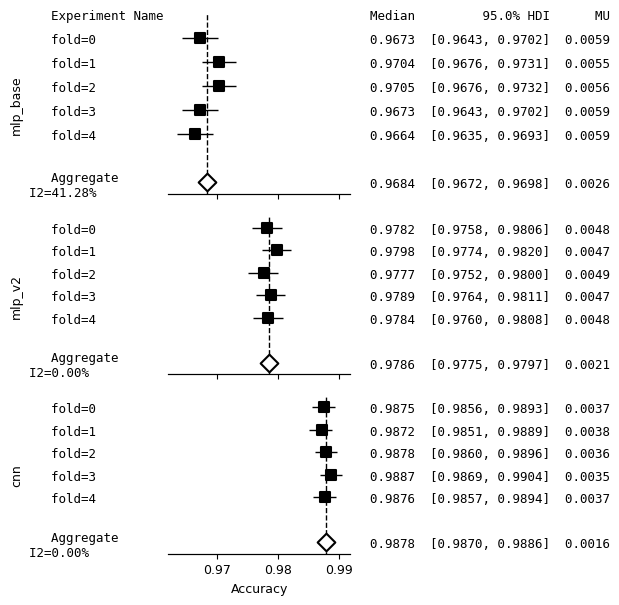

In [51]:
study.plot_forest_plot(metric="acc");

In [52]:
print(
    study.report_pairwise_comparison(
        metric="acc",
        experiment_a="mlp_v2/aggregated",
        experiment_b="mlp_base/aggregated",
        min_sig_diff=0.005,
    )
)

Experiment mlp_v2/aggregated's acc being greater than mlp_base/aggregated could be considered 'certain'* (Median Δ=0.0101, 95.00% HDI=[0.0085, 0.0118], p_direction=100.00%).

There is a 100.00% probability that this difference is bidirectionally significant (ROPE=[-0.0050, 0.0050], p_ROPE=0.00%).

Bidirectional significance could be considered 'certain'*.

There is a 100.00% probability that this difference is significantly positive (p_pos=100.00%, p_neg=0.00%).

Relative to two random models (p_ROPE,random=99.81%) significance is inf times more likely.

* These interpretations are based off of loose guidelines, and should change according to the application.


/usr/local/lib/python3.12/dist-packages/prob_conf_mat/experiment_comparison/pairwise.py:128: RuntimeWarning: divide by zero encountered in log10
  log_bf_rope = np.log10(self.bf_rope)


In [53]:
print(
    study.report_pairwise_comparison(
        metric="acc",
        experiment_a="cnn/aggregated",
        experiment_b="mlp_v2/aggregated",
        min_sig_diff=0.005,
    )
)

Experiment cnn/aggregated's acc being greater than mlp_v2/aggregated could be considered 'certain'* (Median Δ=0.0092, 95.00% HDI=[0.0079, 0.0106], p_direction=100.00%).

There is a 100.00% probability that this difference is bidirectionally significant (ROPE=[-0.0050, 0.0050], p_ROPE=0.00%).

Bidirectional significance could be considered 'certain'*.

There is a 100.00% probability that this difference is significantly positive (p_pos=100.00%, p_neg=0.00%).

Relative to two random models (p_ROPE,random=99.85%) significance is inf times more likely.

* These interpretations are based off of loose guidelines, and should change according to the application.


/usr/local/lib/python3.12/dist-packages/prob_conf_mat/study.py:1948: UserWarning: Parameter `plot_obs_point` is True, but one of the experiments has no observation (i.e. aggregated). As a result, no observed difference will be shown.
  warnings.warn(


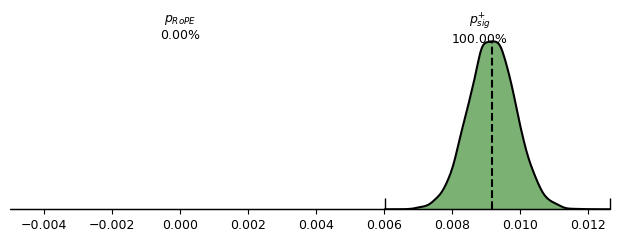

In [54]:
study.plot_pairwise_comparison(
    metric="acc",
    experiment_a="cnn/aggregated",
    experiment_b="mlp_v2/aggregated",
    min_sig_diff=0.005,
);

### Per Class

In [86]:
study.add_metric("precision", aggregation="gaussian")
study.add_metric("recall", aggregation="gaussian")
study.add_metric("f1", aggregation="gaussian")

study.add_metric("precision@macro", aggregation="gaussian")
study.add_metric("recall@macro", aggregation="gaussian")
study.add_metric("f1@macro", aggregation="gaussian")

In [ ]:
records = []
for class_label in range(study.num_classes):
    precision_table = study.report_aggregated_metric_summaries(
        metric="precision",
        class_label=class_label,
        table_fmt="pandas",
    ).set_index(keys=["Group"])

    precision_table = precision_table[["Median", "HDI"]].to_dict()

    recall_table = study.report_aggregated_metric_summaries(
        metric="recall",
        class_label=class_label,
        table_fmt="pandas",
    ).set_index(keys=["Group"])

    recall_table = recall_table[["Median", "HDI"]].to_dict()

    f1_table = study.report_aggregated_metric_summaries(
        metric="f1",
        class_label=class_label,
        table_fmt="pandas",
    ).set_index(keys=["Group"])

    f1_table = f1_table[["Median", "HDI"]].to_dict()

    record = [
        {
            "class_label": class_label,
            ("Precision", "mlp_base"): f"{precision_table['Median']['mlp_base']:.4f}",
            ("Precision", "mlp_v2"): f"{precision_table['Median']['mlp_v2']:.4f}",
            ("Precision", "cnn"): f"{precision_table['Median']['cnn']:.4f}",
            ("Recall", "mlp_base"): f"{recall_table['Median']['mlp_base']:.4f}",
            ("Recall", "mlp_v2"): f"{recall_table['Median']['mlp_v2']:.4f}",
            ("Recall", "cnn"): f"{recall_table['Median']['cnn']:.4f}",
            ("F1", "mlp_base"): f"{f1_table['Median']['mlp_base']:.4f}",
            ("F1", "mlp_v2"): f"{f1_table['Median']['mlp_v2']:.4f}",
            ("F1", "cnn"): f"{f1_table['Median']['cnn']:.4f}",
        },
        {
            "class_label": class_label,
            ("Precision", "mlp_base"): precision_table["HDI"]["mlp_base"],
            ("Precision", "mlp_v2"): precision_table["HDI"]["mlp_v2"],
            ("Precision", "cnn"): precision_table["HDI"]["cnn"],
            ("Recall", "mlp_base"): recall_table["HDI"]["mlp_base"],
            ("Recall", "mlp_v2"): recall_table["HDI"]["mlp_v2"],
            ("Recall", "cnn"): recall_table["HDI"]["cnn"],
            ("F1", "mlp_base"): f1_table["HDI"]["mlp_base"],
            ("F1", "mlp_v2"): f1_table["HDI"]["mlp_v2"],
            ("F1", "cnn"): f1_table["HDI"]["cnn"],
        },
    ]

    records.extend(record)

# Macro
precision_table = study.report_aggregated_metric_summaries(
    metric="precision@macro",
    class_label=None,
    table_fmt="pandas",
).set_index(keys=["Group"])

precision_table = precision_table[["Median", "HDI"]].to_dict()

recall_table = study.report_aggregated_metric_summaries(
    metric="recall@macro",
    class_label=None,
    table_fmt="pandas",
).set_index(keys=["Group"])

recall_table = recall_table[["Median", "HDI"]].to_dict()

f1_table = study.report_aggregated_metric_summaries(
    metric="f1@macro",
    class_label=None,
    table_fmt="pandas",
).set_index(keys=["Group"])

f1_table = f1_table[["Median", "HDI"]].to_dict()

record = [
    {
        "class_label": "Macro",
        ("Precision", "mlp_base"): f"{precision_table['Median']['mlp_base']:.4f}",
        ("Precision", "mlp_v2"): f"{precision_table['Median']['mlp_v2']:.4f}",
        ("Precision", "cnn"): f"{precision_table['Median']['cnn']:.4f}",
        ("Recall", "mlp_base"): f"{recall_table['Median']['mlp_base']:.4f}",
        ("Recall", "mlp_v2"): f"{recall_table['Median']['mlp_v2']:.4f}",
        ("Recall", "cnn"): f"{recall_table['Median']['cnn']:.4f}",
        ("F1", "mlp_base"): f"{f1_table['Median']['mlp_base']:.4f}",
        ("F1", "mlp_v2"): f"{f1_table['Median']['mlp_v2']:.4f}",
        ("F1", "cnn"): f"{f1_table['Median']['cnn']:.4f}",
    },
    {
        "class_label": "Macro",
        ("Precision", "mlp_base"): precision_table["HDI"]["mlp_base"],
        ("Precision", "mlp_v2"): precision_table["HDI"]["mlp_v2"],
        ("Precision", "cnn"): precision_table["HDI"]["cnn"],
        ("Recall", "mlp_base"): recall_table["HDI"]["mlp_base"],
        ("Recall", "mlp_v2"): recall_table["HDI"]["mlp_v2"],
        ("Recall", "cnn"): recall_table["HDI"]["cnn"],
        ("F1", "mlp_base"): f1_table["HDI"]["mlp_base"],
        ("F1", "mlp_v2"): f1_table["HDI"]["mlp_v2"],
        ("F1", "cnn"): f1_table["HDI"]["cnn"],
    },
]

records.extend(record)

In [ ]:
table = pd.DataFrame.from_records(records).set_index("class_label")

table.columns = pd.MultiIndex.from_tuples(
    [
        ("Precision", "mlp_base"),
        ("Precision", "mlp_v2"),
        ("Precision", "cnn"),
        ("Recall", "mlp_base"),
        ("Recall", "mlp_v2"),
        ("Recall", "cnn"),
        ("F1", "mlp_base"),
        ("F1", "mlp_v2"),
        ("F1", "cnn"),
    ]
)

table

Precision                                      \
                     mlp_base            mlp_v2               cnn   
class_label                                                         
0                      0.9808            0.9887            0.9919   
0            [0.9775, 0.9840]  [0.9861, 0.9910]  [0.9897, 0.9940]   
1                      0.9770            0.9811            0.9924   
1            [0.9738, 0.9804]  [0.9781, 0.9841]  [0.9906, 0.9944]   
2                      0.9625            0.9754            0.9884   
2            [0.9579, 0.9668]  [0.9718, 0.9791]  [0.9859, 0.9909]   
3                      0.9568            0.9756            0.9955   
3            [0.9520, 0.9612]  [0.9719, 0.9791]  [0.9939, 0.9971]   
4                      0.9684            0.9851            0.9891   
4            [0.9645, 0.9726]  [0.9822, 0.9880]  [0.9865, 0.9915]   
5                      0.9720            0.9775            0.9897   
5            [0.9679, 0.9761]  [0.9740, 0.9812]  [0.9871, 0.9920]   
6                      0.9855            0.9858            0.9887   
6            [0.9828, 0.9884]  [0.9831, 0.9886]  [0.9862, 0.9912]   
7                      0.9682            0.9778            0.9823   
7            [0.9641, 0.9721]  [0.9745, 0.9811]  [0.9791, 0.9852]   
8                      0.9686            0.9830            0.9862   
8            [0.9645, 0.9730]  [0.9799, 0.9861]  [0.9835, 0.9890]   
9                      0.9544            0.9724            0.9847   
9            [0.9493, 0.9591]  [0.9686, 0.9762]  [0.9818, 0.9875]   
Macro                  0.9685            0.9787            0.9878   
Macro        [0.9672, 0.9698]  [0.9776, 0.9797]  [0.9870, 0.9886]   

                       Recall                                      \
                     mlp_base            mlp_v2               cnn   
class_label                                                         
0                      0.9848            0.9885            0.9963   
0            [0.9819, 0.9877]  [0.9858, 0.9909]  [0.9949, 0.9977]   
1                      0.9866            0.9912            0.9949   
1            [0.9841, 0.9890]  [0.9892, 0.9933]  [0.9934, 0.9965]   
2                      0.9687            0.9822            0.9855   
2            [0.9648, 0.9728]  [0.9791, 0.9853]  [0.9827, 0.9883]   
3                      0.9623            0.9739            0.9834   
3            [0.9580, 0.9666]  [0.9702, 0.9776]  [0.9804, 0.9863]   
4                      0.9690            0.9801            0.9909   
4            [0.9649, 0.9731]  [0.9766, 0.9833]  [0.9885, 0.9929]   
5                      0.9580            0.9787            0.9867   
5            [0.9529, 0.9629]  [0.9752, 0.9822]  [0.9839, 0.9894]   
6                      0.9784            0.9869            0.9939   
6            [0.9749, 0.9819]  [0.9841, 0.9896]  [0.9920, 0.9957]   
7                      0.9770            0.9870            0.9924   
7            [0.9734, 0.9803]  [0.9845, 0.9897]  [0.9904, 0.9944]   
8                      0.9436            0.9558            0.9796   
8            [0.9382, 0.9490]  [0.9509, 0.9606]  [0.9762, 0.9829]   
9                      0.9582            0.9725            0.9801   
9            [0.9536, 0.9629]  [0.9687, 0.9764]  [0.9767, 0.9833]   
Macro                  0.9681            0.9783            0.9876   
Macro        [0.9668, 0.9693]  [0.9772, 0.9794]  [0.9868, 0.9885]   

                           F1                                      
                     mlp_base            mlp_v2               cnn  
class_label                                                        
0                      0.9827            0.9885            0.9932  
0            [0.9806, 0.9849]  [0.9868, 0.9903]  [0.9919, 0.9947]  
1                      0.9808            0.9849            0.9923  
1            [0.9786, 0.9830]  [0.9830, 0.9868]  [0.9910, 0.9937]  
2                      0.9653            0.9784            0.9861  
2            [0.9622, 0.